In [1]:
import json
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
def extract_labels(data_list, label_field, is_ground_truth=True):
    """
    Flattens the nested JSON structure into a dictionary mapping ID -> Label.
    """
    extracted = {}
    
    for item in data_list:
        # Extract Post ID
        post_id = item.get("ID")
        
        # Ground truths use 'label', predictions use 'Overall_Document_Polarity'
        if post_id and label_field in item:
            # Lowercase and strip to ensure "Negative" and "negative" are matched properly
            extracted[post_id] = str(item[label_field]).lower().strip()
            
        # Extract Comment IDs
        # We check both "comment_id" and "ID" to be safe, depending on your schema
        for comment in item.get("Comments", []):
            comment_id = comment.get("comment_id", comment.get("ID"))
            if comment_id and label_field in comment:
                extracted[comment_id] = str(comment[label_field]).lower().strip()
                
    return extracted

In [3]:
# 1. Load the JSON files
# Replace these strings with your actual file paths
GROUND_TRUTH_FILE = Path("../../data/processed/db_labelled.json")
PREDICTIONS_FILE = Path("../../data/results/classified_eval_transformer_only.json")

with open(GROUND_TRUTH_FILE, 'r', encoding='utf-8') as f:
    ground_truth_data = json.load(f)
    
with open(PREDICTIONS_FILE, 'r', encoding='utf-8') as f:
    predictions_data = json.load(f)

# 2. Extract the flattened dictionaries
gt_dict = extract_labels(ground_truth_data, label_field="label")
pred_dict = extract_labels(predictions_data, label_field="Overall_Document_Polarity")

# 3. Match the labels based on the Ground Truth IDs
y_true = []
y_pred = []
matched_ids = []
missing_ids = []

for doc_id, true_label in gt_dict.items():
    if doc_id in pred_dict:
        y_true.append(true_label)
        y_pred.append(pred_dict[doc_id])
        matched_ids.append(doc_id)
    else:
        missing_ids.append(doc_id)

print(f"Total Ground Truth records (including comments): {len(gt_dict)}")
print(f"Total Prediction records (including comments): {len(pred_dict)}")
print(f"Successfully matched records: {len(y_true)}")
print(f"Ground truth records missing from predictions: {len(missing_ids)}")

Total Ground Truth records (including comments): 2166
Total Prediction records (including comments): 2166
Successfully matched records: 2166
Ground truth records missing from predictions: 0


In [4]:
# Define the specific labels we expect to evaluate
expected_labels = ["positive", "negative", "neutral", "irrelevant"]

# Generate the classification report
report = classification_report(
    y_true, 
    y_pred, 
    labels=expected_labels,
    target_names=[label.capitalize() for label in expected_labels],
    zero_division=0 # Prevents warnings if a class has 0 predictions
)

print("--- Sentiment Pipeline Evaluation Report ---\n")
print(report)

--- Sentiment Pipeline Evaluation Report ---

              precision    recall  f1-score   support

    Positive       0.35      0.12      0.18       436
    Negative       0.43      0.14      0.21       540
     Neutral       0.32      0.89      0.47       656
  Irrelevant       0.00      0.00      0.00       534

    accuracy                           0.33      2166
   macro avg       0.27      0.29      0.21      2166
weighted avg       0.27      0.33      0.23      2166



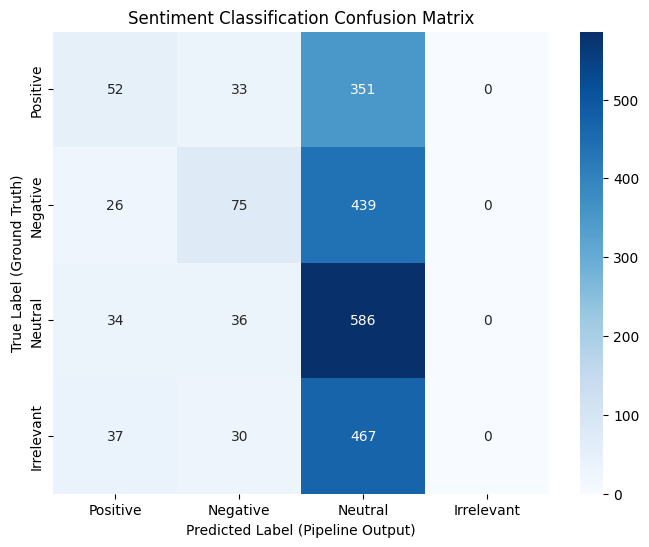

In [5]:
# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=expected_labels)

# Plotting using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=[l.capitalize() for l in expected_labels],
    yticklabels=[l.capitalize() for l in expected_labels]
)

plt.title('Sentiment Classification Confusion Matrix')
plt.xlabel('Predicted Label (Pipeline Output)')
plt.ylabel('True Label (Ground Truth)')
plt.show()